**Clone Github repo and set working directory path**

In [ ]:
!git clone https://github.com/jamal94sm/TIHM.git
%cd /content/TIHM

Cloning into 'TIHM'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 102 (delta 38), reused 12 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 23.96 MiB | 3.91 MiB/s, done.
Resolving deltas: 100% (38/38), done.
Updating files: 100% (27/27), done.
/content/TIHM


In [ ]:
#!rm -r TIHM

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import cm
import matplotlib.patches as mpatches
from collections.abc import Iterable
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from matplotlib import cm
#from utils import *

%matplotlib inline
## Set colour palette
ibm_colorblind = ['#648FFF', '#FE6100', '#DC267F', '#785EF0', '#FFB000','#48A9A6']
sns.set_palette(ibm_colorblind)

In [ ]:
def correct_col_type(df,col):
    raw_type = str(type(df[col].dtype)).split('.')[-1].split('\'')[0].lower()
    #print(col,raw_type)
    if 'object' in raw_type:
        if 'date' in col or 'timestamp' in col or 'datetime' in col:
            return pd.to_datetime(df[col])
        else:
            return df[col].astype('category')
    else:
        return df[col]


def gen_date_col(df, tcol):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df[tcol].dt.date
    return df

In [ ]:
## Please change the path with the path of your dataset
DPATH = './Dataset'
SAVE_PATH = './Figs/'
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)



**Import Files**

In [ ]:
### Labels
f = 'Labels.csv'
fpth = os.path.join(DPATH,f)
labels_df = pd.read_csv(fpth)
for col in labels_df.columns:
    labels_df[col] = correct_col_type(labels_df,col)
if 'date' in labels_df.columns:
    labels_df = labels_df.rename(columns={'date':'timestamp'})
if 'type' in labels_df.columns:
    labels_df = labels_df.rename(columns={'type':'label'})
labels_df = gen_date_col(labels_df,tcol='timestamp')

labels_patients = np.unique(labels_df['patient_id'])


In [ ]:
### Physiology
f = 'Physiology.csv'
fpth = os.path.join(DPATH,f)
df = pd.read_csv(fpth)
for col in df.columns:
    df[col] = correct_col_type(df,col)
if 'date' in df.columns:
    physiology_df = df.rename(columns={'date':'timestamp'})
physiology_df = gen_date_col(physiology_df,tcol='timestamp')

physiology_patients = np.unique(df['patient_id'])
physiology_parameters = np.unique(df['device_type']).tolist()


In [ ]:
### Activity

f = 'Activity.csv'
fpth = os.path.join(DPATH,f)
df = pd.read_csv(fpth)
for col in df.columns:
    df[col] = correct_col_type(df,col)
if 'date' in df.columns:
    activity_df = df.rename(columns={'date':'timestamp'})
    activity_df['timestamp'] = pd.to_datetime(activity_df['timestamp'])
    activity_df['date'] = activity_df['timestamp'].dt.date
    activity_df['time'] = activity_df['timestamp'].dt.time


activity_patients = np.unique(activity_df['patient_id'])

activity_df

,patient_id,location_name,timestamp,date,time
0,0697d,Fridge Door,2019-06-28 13:03:29,2019-06-28,13:03:29
1,0697d,Kitchen,2019-06-28 13:11:44,2019-06-28,13:11:44
2,0697d,Front Door,2019-06-28 13:13:50,2019-06-28,13:13:50
3,0697d,Bedroom,2019-06-28 13:13:53,2019-06-28,13:13:53
4,0697d,Fridge Door,2019-06-28 13:14:09,2019-06-28,13:14:09
...,...,...,...,...,...
1030554,fd100,Hallway,2019-06-30 23:48:50,2019-06-30,23:48:50
1030555,fd100,Lounge,2019-06-30 23:49:40,2019-06-30,23:49:40
1030556,fd100,Kitchen,2019-06-30 23:50:02,2019-06-30,23:50:02
1030557,fd100,Front Door,2019-06-30 23:51:28,2019-06-30,23:51:28


In [ ]:
activity_types = np.unique(activity_df['location_name'])
activity_types

array(['Back Door', 'Bathroom', 'Bedroom', 'Fridge Door', 'Front Door',
       'Hallway', 'Kitchen', 'Lounge'], dtype=object)

In [ ]:
### patient id
id = '16f4b' # 11 agitation days, and 89 record day (78 normal days vs 11 agitation days)
id_activity_df = activity_df[activity_df['patient_id']==id]

# Patient Activity Types
id_activity_types = np.unique(id_activity_df['location_name'])


# Print the results
print(id_activity_df)

       patient_id location_name           timestamp        date      time
80264       16f4b       Hallway 2019-04-01 00:05:46  2019-04-01  00:05:46
80265       16f4b       Hallway 2019-04-01 04:55:16  2019-04-01  04:55:16
80266       16f4b       Bedroom 2019-04-01 05:10:33  2019-04-01  05:10:33
80267       16f4b       Kitchen 2019-04-01 10:15:09  2019-04-01  10:15:09
80268       16f4b      Bathroom 2019-04-01 10:15:53  2019-04-01  10:15:53
...           ...           ...                 ...         ...       ...
113325      16f4b       Kitchen 2019-06-30 23:27:28  2019-06-30  23:27:28
113326      16f4b      Bathroom 2019-06-30 23:27:41  2019-06-30  23:27:41
113327      16f4b      Bathroom 2019-06-30 23:45:26  2019-06-30  23:45:26
113328      16f4b      Bathroom 2019-06-30 23:46:39  2019-06-30  23:46:39
113329      16f4b       Hallway 2019-06-30 23:47:22  2019-06-30  23:47:22

[33066 rows x 5 columns]


# **Visualize Original Activity Sequences**

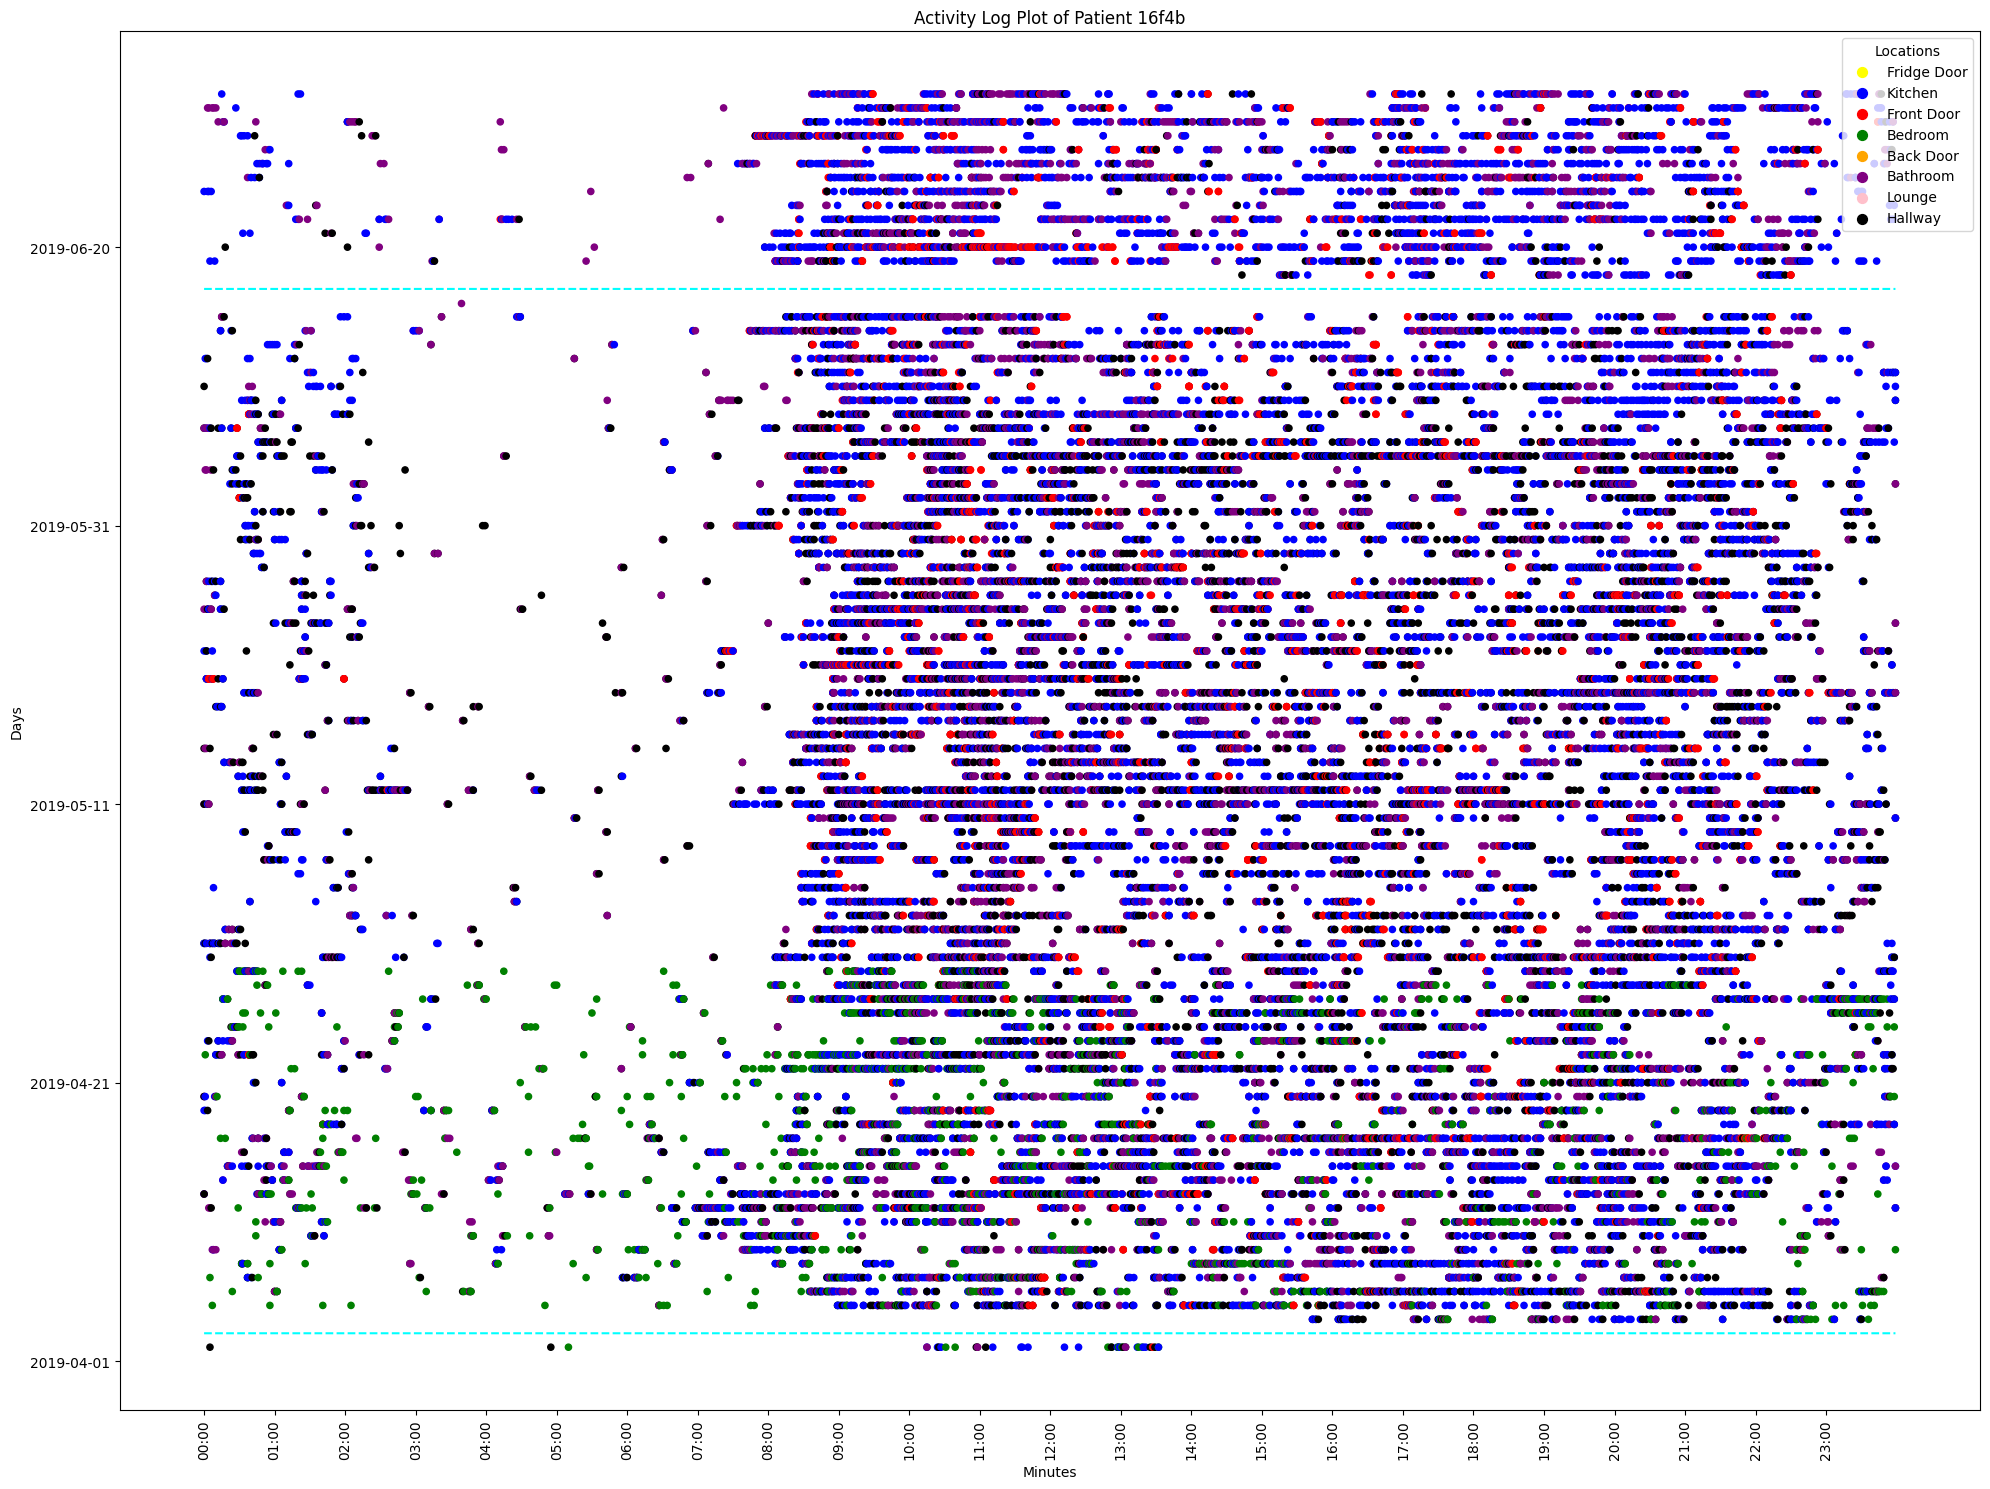

In [ ]:
def find_missing_dates(timestamp_list):
    # Convert list to pandas DatetimeIndex
    date_index = pd.to_datetime(timestamp_list)

    # Get the range of dates from the first to the last date
    all_dates = pd.date_range(start=date_index.min(), end=date_index.max())

    # Find missing dates
    missing_dates = all_dates.difference(date_index)

    missing_dates = [d.date() for d in missing_dates]
    all_dates = [d.date() for d in all_dates]

    return missing_dates, all_dates


date_min = activity_df.date.min()
date_max = activity_df.date.max()
date_period_length = activity_df.date.nunique()
freq = 20
date_labels = pd.date_range(start=date_min, end=date_max, freq=f'{freq}D').strftime('%Y-%m-%d')

# Parameters
day_window = 100  # the window of days
df_id = id_activity_df
date_id = np.unique(df_id['date'])
missing_days, all_dates = find_missing_dates(date_id)
# Mapping dictionary
color_mapping = {
    'Fridge Door': 'yellow',
    'Kitchen': 'blue',
    'Front Door': 'red',
    'Bedroom': 'green',
    'Back Door': 'orange',
    'Bathroom': 'purple',
    'Lounge': 'pink',
    'Hallway': 'black'
}

# Create a list of time strings in the format HH:MM from 00:00 to 23:59 with a frequency of 1 minute
time_strings = [f"{i:02}:{j:02}" for i in range(24) for j in range(60)]

# Plotting
fig, ax = plt.subplots(figsize=(20, 15))  # Increased the figure size for larger plot area
for day in range(min(len(all_dates), day_window)):
    if all_dates[day] in missing_days:
        plt.plot(range(len(time_strings)), [day + 1] * len(time_strings), color='cyan', linestyle='--')
    else:
        location_id = df_id[df_id['date'] == all_dates[day]]['location_name'].tolist()
        timestamp_id = df_id[df_id['date'] == all_dates[day]]['timestamp'].tolist()

        # Convert the smaller list of Timestamps to "hour:min" format
        small_time_strings = [ts.strftime("%H:%M") for ts in timestamp_id]

        # Find the indices of the elements of the smaller list in the larger list
        indices = [time_strings.index(time) for time in small_time_strings if time in time_strings]

        # Changing the elements in list A according to the mapping
        color_map = [color_mapping[loc] for loc in location_id]

        # Create the scatter plot with larger points
        plt.scatter(indices, [day + 1] * len(color_map), color=color_map, s=20)  # Increased marker size

# Add legends
for loc, color in color_mapping.items():
    plt.scatter([], [], color=color, label=loc, s=50)

# Plot formatting
hours = [f"{i//60:02}:{i%60:02}" for i in range(0, len(time_strings), 60)]
plt.xticks(range(0, len(time_strings), 60), hours, rotation=90)  # Set x-ticks to show every hour
plt.yticks(range(0, date_period_length, freq), date_labels)  # Set x-ticks to show every hour

plt.xlabel('Minutes')
plt.ylabel('Days')
plt.title(f'Activity Log Plot of Patient {id}')
plt.legend(title='Locations', loc='upper right')  # Adjust legend position
plt.tight_layout()

plt.show()

# **Activity Data Repairing (Filling the Gaps)**

In [ ]:
# Function to label 'outside' in the 'location_name' column for gaps between 'Front Door' and 'Back Door'
def label_outside(df, threshold_minutes=2):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(by='timestamp')
    new_rows = []

    for i in range(len(df) - 1):
        current_row = df.iloc[i]
        next_row = df.iloc[i + 1]
        current_time = current_row['timestamp']
        next_time = next_row['timestamp']

        # Check if the time difference exceeds the threshold
        if (next_time - current_time).total_seconds() / 60.0 > threshold_minutes:
            if (current_row['location_name'] in ['Front Door', 'Back Door'])  and (next_row['location_name'] in ['Front Door', 'Back Door']):
                while (next_time - current_time).total_seconds() / 60.0 > threshold_minutes:
                    current_time += pd.Timedelta(minutes=threshold_minutes)
                    if current_time >= next_time:
                        break
                    new_row = current_row.copy()
                    new_row['timestamp'] = current_time
                    new_row['location_name'] = 'outside'
                    new_rows.append(new_row)

    df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True).sort_values(by='timestamp').reset_index(drop=True)
    return df

# Function to check if a time is between 10:00 PM and 8:00 AM
def is_night(time):
    return time >= pd.Timestamp("22:00:00").time() or time <= pd.Timestamp("08:00:00").time()

# Function to fill night gaps with 'Bedroom' entries every 5 minutes
def fill_night_gaps_with_bedroom(df, threshold_minutes=5):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(by='timestamp')

    new_rows = []
    for i in range(len(df) - 1):
        current_row = df.iloc[i]
        next_row = df.iloc[i + 1]
        current_time = current_row['timestamp']
        next_time = next_row['timestamp']

        while (next_time - current_time).total_seconds() / 60.0 > threshold_minutes and is_night(current_time.time()):
            current_time += pd.Timedelta(minutes=threshold_minutes)
            if current_time >= next_time:
                break
            new_row = current_row.copy()
            new_row['timestamp'] = current_time
            new_row['location_name'] = 'Bedroom'
            new_rows.append(new_row)

    df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True).sort_values(by='timestamp').reset_index(drop=True)
    return df

# Function to fill gaps with forward fill and backward fill for specified locations
def fill_gaps_with_forward_backward(df, threshold_minutes=3):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(by='timestamp')

    backward_fill_locations = ['Front Door', 'Back Door', 'Fridge Door']
    new_rows = []

    for i in range(len(df) - 1):
        current_row = df.iloc[i]
        next_row = df.iloc[i + 1]
        current_time = current_row['timestamp']
        next_time = next_row['timestamp']

        if (next_time - current_time).total_seconds() / 60.0 > threshold_minutes:
            if current_row['location_name'] in backward_fill_locations and next_row['location_name'] not in backward_fill_locations:
                # Perform backward fill for the whole gap
                fill_time = next_time
                while (fill_time - current_time).total_seconds() / 60.0 > threshold_minutes:
                    fill_time -= pd.Timedelta(minutes=threshold_minutes)
                    if fill_time <= current_time:
                        break
                    new_row = next_row.copy()
                    new_row['timestamp'] = fill_time
                    new_row['location_name'] = next_row['location_name']
                    new_rows.append(new_row)
            else:
                # Perform forward fill for the whole gap
                fill_time = current_time
                while (next_time - fill_time).total_seconds() / 60.0 > threshold_minutes:
                    fill_time += pd.Timedelta(minutes=threshold_minutes)
                    if fill_time >= next_time:
                        break
                    new_row = current_row.copy()
                    new_row['timestamp'] = fill_time
                    new_row['location_name'] = current_row['location_name']
                    new_rows.append(new_row)

    df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True).sort_values(by='timestamp').reset_index(drop=True)
    return df


# Step 1: Label 'outside' gaps for front and back doors
id_repaired_activity_df = label_outside(id_activity_df, threshold_minutes=2)

# Step 2: Fill night gaps with 'Bedroom'
id_repaired_activity_df = fill_night_gaps_with_bedroom(id_repaired_activity_df, threshold_minutes=5)

# Step 3: Fill gaps with forward and backward fills
id_repaired_activity_df = fill_gaps_with_forward_backward(id_repaired_activity_df, threshold_minutes=3)

# Display the repaired dataframe
id_repaired_activity_df


,patient_id,location_name,timestamp,date,time
0,16f4b,Hallway,2019-04-01 00:05:46,2019-04-01,00:05:46
1,16f4b,Hallway,2019-04-01 00:08:46,2019-04-01,00:05:46
2,16f4b,Bedroom,2019-04-01 00:10:46,2019-04-01,00:05:46
3,16f4b,Bedroom,2019-04-01 00:13:46,2019-04-01,00:05:46
4,16f4b,Bedroom,2019-04-01 00:15:46,2019-04-01,00:05:46
...,...,...,...,...,...
69999,16f4b,Bedroom,2019-06-30 23:40:41,2019-06-30,23:27:41
70000,16f4b,Bedroom,2019-06-30 23:42:41,2019-06-30,23:27:41
70001,16f4b,Bathroom,2019-06-30 23:45:26,2019-06-30,23:45:26
70002,16f4b,Bathroom,2019-06-30 23:46:39,2019-06-30,23:46:39


# **Visualize the repaired data**

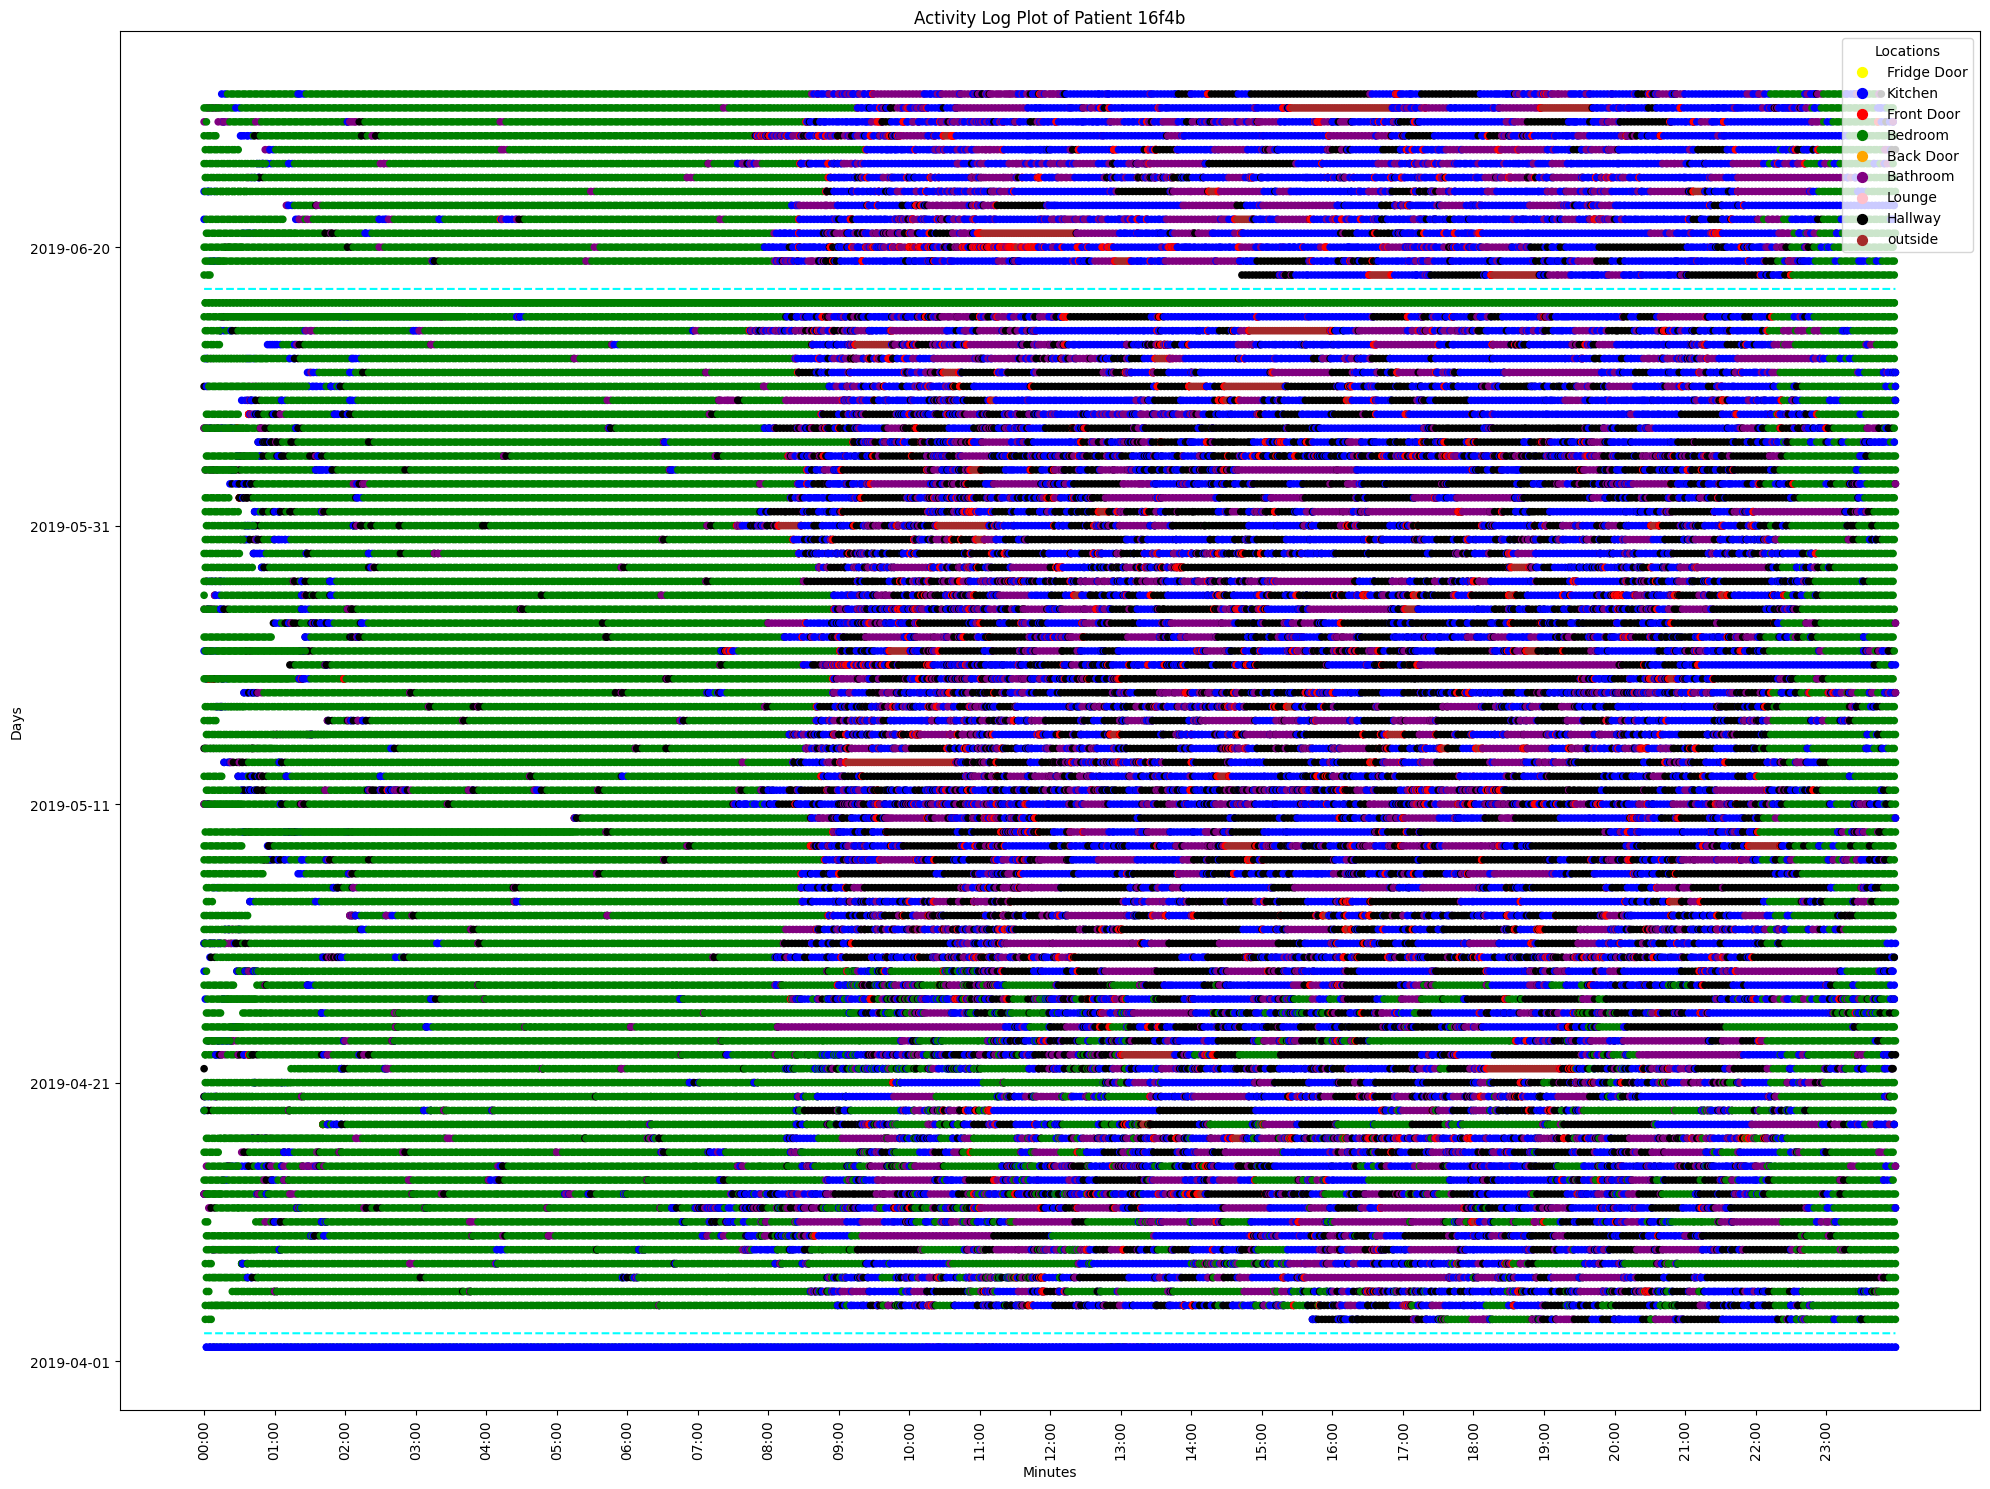

In [ ]:
# Parameters
day_window = 100  # the window of days
df_id = id_repaired_activity_df
date_id = np.unique(df_id['date'])
missing_days, all_dates = find_missing_dates(date_id)
# Mapping dictionary
color_mapping = {
    'Fridge Door': 'yellow',
    'Kitchen': 'blue',
    'Front Door': 'red',
    'Bedroom': 'green',
    'Back Door': 'orange',
    'Bathroom': 'purple',
    'Lounge': 'pink',
    'Hallway': 'black',
    'outside': 'brown'
}

# Create a list of time strings in the format HH:MM from 00:00 to 23:59 with a frequency of 1 minute
time_strings = [f"{i:02}:{j:02}" for i in range(24) for j in range(60)]

# Plotting
fig, ax = plt.subplots(figsize=(20, 15))  # Increased the figure size for larger plot area
for day in range(min(len(all_dates), day_window)):
    if all_dates[day] in missing_days:
        plt.plot(range(len(time_strings)), [day + 1] * len(time_strings), color='cyan', linestyle='--')
    else:
        location_id = df_id[df_id['date'] == all_dates[day]]['location_name'].tolist()
        timestamp_id = df_id[df_id['date'] == all_dates[day]]['timestamp'].tolist()

        # Convert the smaller list of Timestamps to "hour:min" format
        small_time_strings = [ts.strftime("%H:%M") for ts in timestamp_id]

        # Find the indices of the elements of the smaller list in the larger list
        indices = [time_strings.index(time) for time in small_time_strings if time in time_strings]

        # Changing the elements in list A according to the mapping
        color_map = [color_mapping[loc] for loc in location_id]

        # Create the scatter plot with larger points
        plt.scatter(indices, [day + 1] * len(color_map), color=color_map, s=20)  # Increased marker size

# Add legends
for loc, color in color_mapping.items():
    plt.scatter([], [], color=color, label=loc, s=50)

# Plot formatting
hours = [f"{i//60:02}:{i%60:02}" for i in range(0, len(time_strings), 60)]
plt.xticks(range(0, len(time_strings), 60), hours, rotation=90)  # Set x-ticks to show every hour
plt.yticks(range(0, date_period_length, freq), date_labels)  # Set x-ticks to show every hour

plt.xlabel('Minutes')
plt.ylabel('Days')
plt.title(f'Activity Log Plot of Patient {id}')
plt.legend(title='Locations', loc='upper right')  # Adjust legend position
plt.tight_layout()

plt.show()